These codes are adapted from **An Introduction to Statistical Learning with Applications in Python** (pp. 273 - 280)
https://www.statlearning.com/

In [ ]:
# Loading libraries
import pandas as pd # Libraries for processing data
import numpy as np

from matplotlib.pyplot import subplots # Libraries for plotting graphs

from sklearn.preprocessing import StandardScaler # Libraries for implementing ladge, lasso regression and elasticnet
from sklearn.pipeline import Pipeline
import sklearn.linear_model as skl
import sklearn.model_selection as skm

#### 📝 Our goal: Identifying important features for predicting a customer's credit card balance!

## 1. Data preparation

In [ ]:
# Mounting google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# Loading data
credit = pd.read_csv('/content/gdrive/MyDrive/2025_IPS_Data/dataset/Credit.csv')

In [ ]:
credit.head() # head(): show the upper 5 rows of the dataset

,Income,Limit,Rating,Cards,Age,Education,Own,Student,Married,Region,Balance
0,14.891,3606,283,2,34,11,No,No,Yes,South,333
1,106.025,6645,483,3,82,15,Yes,Yes,Yes,West,903
2,104.593,7075,514,4,71,11,No,No,No,West,580
3,148.924,9504,681,3,36,11,Yes,No,No,West,964
4,55.882,4897,357,2,68,16,No,No,Yes,South,331


In [ ]:
# If you want to see more rows? use indexing -> credit[:number of rows]
credit[:10]

,Income,Limit,Rating,Cards,Age,Education,Own,Student,Married,Region,Balance
0,14.891,3606,283,2,34,11,No,No,Yes,South,333
1,106.025,6645,483,3,82,15,Yes,Yes,Yes,West,903
2,104.593,7075,514,4,71,11,No,No,No,West,580
3,148.924,9504,681,3,36,11,Yes,No,No,West,964
4,55.882,4897,357,2,68,16,No,No,Yes,South,331
5,80.180,8047,569,4,77,10,No,No,No,South,1151
6,20.996,3388,259,2,37,12,Yes,No,No,East,203
7,71.408,7114,512,2,87,9,No,No,No,West,872
8,15.125,3300,266,5,66,13,Yes,No,No,South,279
9,71.061,6819,491,3,41,19,Yes,Yes,Yes,East,1350


In [8]:
# Checking missing data
rows_with_nan = credit[credit.isnull().any(axis=1)]
print(rows_with_nan)

Empty DataFrame
Columns: [Income, Limit, Rating, Cards, Age, Education, Own, Student, Married, Region, Balance]
Index: []


In [9]:
# Separating predictors (features) and outcome data

# Predictors
X = credit[['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education']]

# Outcome
y = credit['Balance']

In [10]:
X.head()

,Income,Limit,Rating,Cards,Age,Education
0,14.891,3606,283,2,34,11
1,106.025,6645,483,3,82,15
2,104.593,7075,514,4,71,11
3,148.924,9504,681,3,36,11
4,55.882,4897,357,2,68,16


In [11]:
y.head()

,Balance
0,333
1,903
2,580
3,964
4,331


## 2. Regularized linear regression models: Ridge, Lasso, ElasticNet

In [12]:
# Configuring train-test split

# 1. Outer validation (for estimating test error): simple validation
outer_valid = skm.ShuffleSplit(n_splits = 1, # number of splitting
                               test_size = 0.25, # the proportion of the dataset to include in the test split
                               random_state = 123)

# 2. Inner validation (for identifying optimal lambda value): k-fold cross-validation
K = 10
inner_valid = skm.KFold(K, # number of folds
                        random_state = 123,
                        shuffle=True) # whether to suffle the data before splitting

### 1. Ridge regression

In [13]:
lambdas = 10 ** np.linspace(8, -2, 100) # generating 100 numbers in the range from 10^-2 to 10^8 with equally spaced intervals

In [17]:
lambdas

array([1.00000000e+08, 7.92482898e+07, 6.28029144e+07, 4.97702356e+07,
       3.94420606e+07, 3.12571585e+07, 2.47707636e+07, 1.96304065e+07,
       1.55567614e+07, 1.23284674e+07, 9.77009957e+06, 7.74263683e+06,
       6.13590727e+06, 4.86260158e+06, 3.85352859e+06, 3.05385551e+06,
       2.42012826e+06, 1.91791026e+06, 1.51991108e+06, 1.20450354e+06,
       9.54548457e+05, 7.56463328e+05, 5.99484250e+05, 4.75081016e+05,
       3.76493581e+05, 2.98364724e+05, 2.36448941e+05, 1.87381742e+05,
       1.48496826e+05, 1.17681195e+05, 9.32603347e+04, 7.39072203e+04,
       5.85702082e+04, 4.64158883e+04, 3.67837977e+04, 2.91505306e+04,
       2.31012970e+04, 1.83073828e+04, 1.45082878e+04, 1.14975700e+04,
       9.11162756e+03, 7.22080902e+03, 5.72236766e+03, 4.53487851e+03,
       3.59381366e+03, 2.84803587e+03, 2.25701972e+03, 1.78864953e+03,
       1.41747416e+03, 1.12332403e+03, 8.90215085e+02, 7.05480231e+02,
       5.59081018e+02, 4.43062146e+02, 3.51119173e+02, 2.78255940e+02,
      

In [15]:
# Standardizing data
scaler = StandardScaler(with_mean = True, # if True, center the data before scaling
                        with_std = True) # if Ture, scale the data ot unit variance

# Configuring model
ridgeCV = skl.ElasticNetCV(alphas=lambdas, # list of alphas (alpha = lambda)
                           # n_alphas = 100, # number of alphas
                           l1_ratio=0, # 0 = ridge, 1 = lasso, 0 < ratio < 1 = elasticnet
                           max_iter = 10000, # maxinum number of iterations
                           cv=inner_valid) # determine the cross-validation spliting strategy

ridgePipe = Pipeline(steps = [('scaler', scaler), ('ridge', ridgeCV)]) # scaler is only applied to X, not y

In [16]:
# Fitting model with our data
ridge_res = skm.cross_validate(ridgePipe,
                               X,
                               y,
                               cv=outer_valid,
                               scoring='neg_mean_squared_error',
                               return_estimator=True)

# Fitted model
ridge_model = ridge_res['estimator'][0].named_steps['ridge']

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 28000321.9773758, tolerance: 5600.064487407408
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did n

In [18]:
print('Estimated test error (MSE):', -ridge_res['test_score'][0])

Estimated test error (MSE): 28354.53536810583


In [19]:
print('Selected lambda value:', ridge_model.alpha_)

Selected lambda value: 0.01


In [20]:
# Coefficient values of the model with the selected lambda
ridge_coeff = pd.DataFrame({'ridge_coeff': ridge_model.coef_}, index=X.columns)
ridge_coeff.index.name = 'feature'
ridge_coeff

,ridge_coeff
feature,
Income,-264.779200
Limit,312.784953
Rating,280.664809
Cards,16.148109
Age,-15.560291
Education,1.286474


In [21]:
# Retrieving sigma values from scaler
scaler = ridge_res['estimator'][0].named_steps['scaler']
sigma = scaler.scale_

# Unstandardizing coefficients
ridge_coeff_ori = ridge_model.coef_ / sigma

ridge_coeff_ori = pd.DataFrame({'ridge_coeff': ridge_coeff_ori}, index=X.columns)
ridge_coeff_ori.index.name = 'feature'
ridge_coeff_ori

,ridge_coeff
feature,
Income,-7.684574
Limit,0.138785
Rating,1.855717
Cards,11.495848
Age,-0.896919
Education,0.400806


### 2. Lasso regression

In [23]:
lambdas = 10 ** np.linspace(8, -2, 100) # generating 100 numbers in the range from 10^-2 to 10^8 with equally spaced intervals

In [24]:
# Standardizing data
scaler = StandardScaler(with_mean = True , with_std = True)

# Configuring model
lassoCV = skl.ElasticNetCV(alphas=lambdas,
                           l1_ratio=1,
                           max_iter = 10000,
                           cv=inner_valid)

lassoPipe = Pipeline(steps =[('scaler', scaler), ('lasso', lassoCV)])

In [25]:
# Fitting model with our data
lasso_res = skm.cross_validate(lassoPipe,
                               X,
                               y,
                               cv=outer_valid,
                               scoring='neg_mean_squared_error',
                               return_estimator=True)

# Fitted model
lasso_model = lasso_res['estimator'][0].named_steps['lasso']

In [26]:
print('Estimated test error (MSE):', -lasso_res['test_score'][0])

Estimated test error (MSE): 29019.751898185834


In [27]:
print('Selected lambda value:', lasso_model.alpha_)

Selected lambda value: 1.0476157527896661


In [43]:
# Coefficient values of the model with the selected lambda
lasso_coeff = pd.DataFrame({'lasso_coeff': lasso_model.coef_}, index=X.columns)
lasso_coeff.index.name = 'feature'
lasso_coeff

,lasso_coeff
feature,
Income,-273.327817
Limit,392.676367
Rating,209.148142
Cards,17.827644
Age,-13.904196
Education,0.000000


In [44]:
# Retrieving sigma values from scaler
scaler = lasso_res['estimator'][0].named_steps['scaler']
sigma = scaler.scale_

# Unstandardizing coefficients
lasso_coeff_ori = lasso_model.coef_ / sigma

lasso_coeff_ori = pd.DataFrame({'lasso_coeff': lasso_coeff_ori}, index=X.columns)
lasso_coeff_ori.index.name = 'feature'
lasso_coeff_ori

,lasso_coeff
feature,
Income,-7.932677
Limit,0.174234
Rating,1.382859
Cards,12.691510
Age,-0.801459
Education,0.000000


### 3. ElasticNet

In [28]:
l1_ratios = np.linspace(0, 1, 11) # generating 11 numbers in the range from 0 to 1 with equallity spaced intervals
lambdas = 10 ** np.linspace(8, -2, 100) # generating 100 numbers in the range from 10^-2 to 10^8 with equally spaced intervals

In [29]:
# Standardizing data
scaler = StandardScaler(with_mean = True , with_std = True)

# Configuring model
elasticCV = skl.ElasticNetCV(alphas=lambdas,
                             # n_alphas = 100,
                             l1_ratio=l1_ratios,
                             max_iter=10000,
                             cv=inner_valid)

elasticPipe = Pipeline(steps =[('scaler', scaler), ('elastic', elasticCV)])

In [30]:
# Fitting model with our data
elastic_res = skm.cross_validate(elasticPipe,
                                 X,
                                 y,
                                 cv=outer_valid,
                                 scoring='neg_mean_squared_error',
                                 return_estimator=True)

# Fitted model
elastic_model = elastic_res['estimator'][0].named_steps['elastic']

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 28000321.9773758, tolerance: 5600.064487407408
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did n

In [31]:
print('Estimated test error (MSE):', -elastic_res['test_score'][0])

Estimated test error (MSE): 28792.593858705684


In [32]:
print('Selected lambda value:', elastic_model.alpha_)

Selected lambda value: 0.03199267137797385


In [33]:
print('Selected l1 ratio value:', elastic_model.l1_ratio_)

Selected l1 ratio value: 0.9


In [34]:
# Coefficient values of the model with the selected lambda
elastic_coeff = pd.DataFrame({'elastic_coeff': elastic_model.coef_}, index=X.columns)
elastic_coeff.index.name = 'feature'
elastic_coeff

,elastic_coeff
feature,
Income,-273.474904
Limit,340.210924
Rating,261.980208
Cards,16.521254
Age,-14.983407
Education,1.076746


In [35]:
# Retrieving sigma values from scaler
scaler = elastic_res['estimator'][0].named_steps['scaler']
sigma = scaler.scale_

# Unstandardizing coefficients
elastic_coeff_ori = elastic_model.coef_ / sigma

elastic_coeff_ori = pd.DataFrame({'elastic_coeff': elastic_coeff_ori}, index=X.columns)
elastic_coeff_ori.index.name = 'feature'
elastic_coeff_ori

,elastic_coeff
feature,
Income,-7.936946
Limit,0.150954
Rating,1.732177
Cards,11.761490
Age,-0.863667
Education,0.335465


### 4. Simple regression

In [36]:
# Standardizing data
scaler = StandardScaler(with_mean = True , with_std = True)

# Configuring model
simple = skl.LinearRegression()

simplePipe = Pipeline(steps =[('scaler', scaler), ('simple', simple)])

In [37]:
# Fitting model with our data
simple_res = skm.cross_validate(simplePipe,
                                X,
                                y,
                                cv=outer_valid,
                                scoring='neg_mean_squared_error',
                                return_estimator=True)

# Fitted model
simple_model = simple_res['estimator'][0].named_steps['simple']

In [38]:
print('Estimated test error (MSE):', -simple_res['test_score'][0])

Estimated test error (MSE): 29188.657018184942


In [39]:
# Coefficient values of the model with the selected lambda
simple_coeff = pd.DataFrame({'simple_coeff': simple_model.coef_}, index=X.columns)
simple_coeff.index.name = 'feature'
simple_coeff

,simple_coeff
feature,
Income,-277.784078
Limit,393.788715
Rating,212.581877
Cards,18.515839
Age,-14.639669
Education,0.868098


In [40]:
# Retrieving sigma values from scaler
scaler = simple_res['estimator'][0].named_steps['scaler']
sigma = scaler.scale_

# Unstandardizing coefficients
simple_coeff_ori = simple_model.coef_ / sigma

simple_coeff_ori = pd.DataFrame({'simple_coeff': simple_coeff_ori}, index=X.columns)
simple_coeff_ori.index.name = 'feature'
simple_coeff_ori

,simple_coeff
feature,
Income,-8.062009
Limit,0.174727
Rating,1.405562
Cards,13.181437
Age,-0.843853
Education,0.270459


### 5. Comparing the results

In [41]:
# Estimated test error of each model
testerr_df = pd.DataFrame([[-simple_res['test_score'][0], -ridge_res['test_score'][0], -lasso_res['test_score'][0], -elastic_res['test_score'][0]]], columns=['simple', 'ridge', 'lasso', 'elasticnet'], index=['estimated test error'])
testerr_df

,simple,ridge,lasso,elasticnet
estimated test error,29188.657018,28354.535368,29019.751898,28792.593859


In [45]:
# Standardized coefficients of each model
coeff_df = pd.concat([simple_coeff, ridge_coeff, lasso_coeff, elastic_coeff], axis=1)
coeff_df

,simple_coeff,ridge_coeff,lasso_coeff,elastic_coeff
feature,,,,
Income,-277.784078,-264.779200,-273.327817,-273.474904
Limit,393.788715,312.784953,392.676367,340.210924
Rating,212.581877,280.664809,209.148142,261.980208
Cards,18.515839,16.148109,17.827644,16.521254
Age,-14.639669,-15.560291,-13.904196,-14.983407
Education,0.868098,1.286474,0.000000,1.076746


In [46]:
# Unstandardized coefficients of each model
coeff_ori_df = pd.concat([simple_coeff_ori, ridge_coeff_ori, lasso_coeff_ori, elastic_coeff_ori], axis=1)
coeff_ori_df

,simple_coeff,ridge_coeff,lasso_coeff,elastic_coeff
feature,,,,
Income,-8.062009,-7.684574,-7.932677,-7.936946
Limit,0.174727,0.138785,0.174234,0.150954
Rating,1.405562,1.855717,1.382859,1.732177
Cards,13.181437,11.495848,12.691510,11.761490
Age,-0.843853,-0.896919,-0.801459,-0.863667
Education,0.270459,0.400806,0.000000,0.335465


### **Conclusion for Practice 1**
1. Income, Limit, and Rating were important features for predicting a customer's credit card balance.
2. All three methods (ridge, lasso, and elasticnet) reduced the test error compared to a simple linear model.
2. Compared to ridge and elsticnet, lasso shrank some coefficients to zero.

## (Extra) Model configuration for single fitting

#### 1. ElasticNet()

In [47]:
# Configuring model
res = skl.ElasticNet(alpha=0.5, # alpha = lambda
                     l1_ratio=0, # 0 = ridge, 1 = lasso, 0 < ratio < 1 = elasticnet
                     max_iter = 10000) # maximum number of iterations

# Fitting model
res.fit(X, y)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.151e+06, tolerance: 8.434e+03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


ElasticNet(alpha=0.5, l1_ratio=0, max_iter=10000)

In [48]:
# Result of model fitting
res.coef_

array([-7.56372582,  0.11366207,  2.24667167,  8.43114071, -0.88332758,
        1.89035426])

#### 2. ElasticNet.path()

In [49]:
lambdas = 10 ** np.linspace(8, -2, 100) # generating 100 numbers in the range from 10^-2 to 10^8 with equally spaced intervals

In [50]:
# Configuring and fitting model
res_array = skl.ElasticNet.path(X,
                                y,
                                l1_ratio=0, # 0 = ridge, 1 = lasso, 0 < ratio < 1 = elasticnet
                                alphas=lambdas, # list of alphas
                                #n_alphas=100, # numbers of alpha
                                max_iter = 10000)[1] # maximum number of iterations

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 78345943.61525412, tolerance: 19250.6152
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not con

In [51]:
res_array.shape # (number of predictors, number of lambdas)

(6, 100)

In [52]:
res_path = pd.DataFrame(res_array.T,
                        columns=X.columns,
                        index=-np.log(lambdas)) # transform the values for visualization purpose
res_path.index.name = 'negative log(lambda)'
res_path

feature,Income,Limit,Rating,Cards,Age,Education
negative log(lambda),,,,,,
-18.420681,0.000236,0.026387,0.001918,0.000012,0.000219,0.000053
-18.188096,0.000280,0.031498,0.002289,0.000014,0.000258,0.000063
-17.955512,0.000328,0.037209,0.002702,0.000017,0.000302,0.000073
-17.722928,0.000379,0.043454,0.003152,0.000020,0.000347,0.000085
-17.490343,0.000430,0.050119,0.003632,0.000022,0.000392,0.000096
...,...,...,...,...,...,...
3.674833,-7.043541,0.294274,-0.674113,8.233091,-2.728775,-13.228035
3.907417,-7.043587,0.294386,-0.675757,8.266245,-2.728534,-13.232240
4.140001,-7.043622,0.294475,-0.677071,8.292705,-2.728344,-13.235576


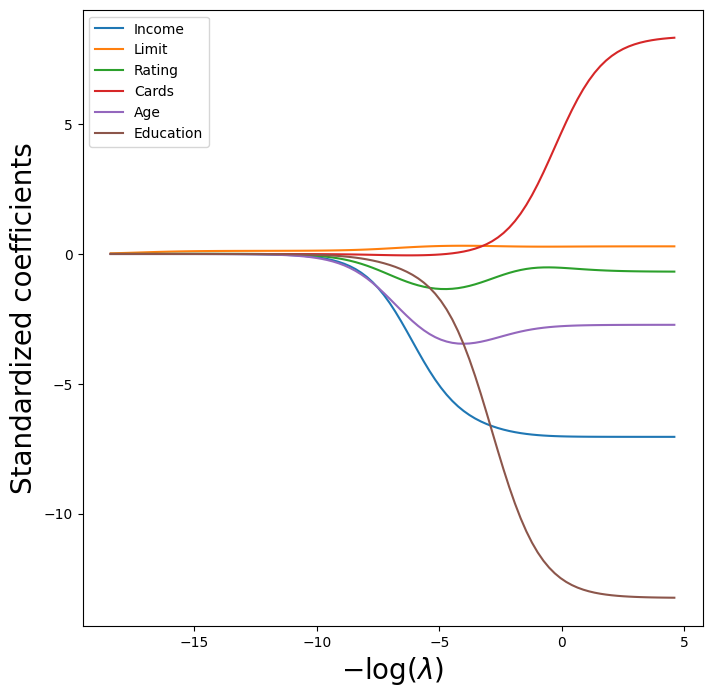

In [53]:
path_fig, ax = subplots(figsize =(8 ,8))
res_path.plot(ax=ax, legend=False)
ax.set_xlabel('$-\log(\lambda)$', fontsize =20)
ax.set_ylabel('Standardized coefficients', fontsize =20)
ax.legend(loc='upper left');